In [ ]:
!nvidia-smi
%pip install torchmetrics[image] -q

In [ ]:
from __future__ import annotations
from typing import Callable, Iterable, Optional

import math
import random
import time
from pathlib import Path
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torchvision.utils as vutils

from torch import Tensor
from torch.optim import Optimizer

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image.fid import FrechetInceptionDistance

In [24]:
SEED = 42  # For robust reporting, run multiple seeds: 42, 6, 11, 96, 22

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class HNAdam(Optimizer):
    def __init__(
        self,
        params: Iterable[Tensor],
        lr: float = 1e-3,
        betas: tuple[float, float] = (0.9, 0.99),
        eps: float = 1e-8,
        lambda_t0: Optional[float] = None,
    ) -> None:
        if params is None:
            raise ValueError("params cannot be None.")
        if lr <= 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if len(betas) != 2:
            raise ValueError("betas must be a tuple of two floats")

        beta1, beta2 = betas
        if not 0.0 <= beta1 < 1.0:
            raise ValueError(f"Invalid beta1 value: {beta1}")
        if not 0.0 <= beta2 < 1.0:
            raise ValueError(f"Invalid beta2 value: {beta2}")

        if lambda_t0 is None:
            lambda_t0 = random.uniform(2.0, 4.0)
        if not 2.0 <= lambda_t0 <= 4.0:
            raise ValueError(f"lambda_t0 must be in [2, 4], got {lambda_t0}")

        defaults = {
            "lr": lr,
            "betas": (beta1, beta2),
            "eps": eps,
            "lambda_t0": lambda_t0,
            "amsgrad": False,
        }
        super().__init__(params, defaults)

        if len(self.param_groups) == 0:
            raise ValueError("optimizer got an empty parameter list")

    @torch.no_grad()
    def step(self, closure: Optional[Callable[[], Tensor]] = None) -> Optional[Tensor]:
        loss: Optional[Tensor] = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr: float = group["lr"]
            beta1, beta2 = group["betas"]
            eps: float = group["eps"]
            lambda_t0: float = group["lambda_t0"]

            for param in group["params"]:
                if param.grad is None:
                    continue

                grad = param.grad
                if grad.is_sparse:
                    raise RuntimeError("HNAdam does not support sparse gradients")

                state = self.state[param]

                if len(state) == 0:
                    state["m"] = torch.zeros_like(param, memory_format=torch.preserve_format)
                    state["v"] = torch.zeros_like(param, memory_format=torch.preserve_format)
                    state["vhat"] = torch.zeros_like(param, memory_format=torch.preserve_format)

                m_prev: Tensor = state["m"]
                v_prev: Tensor = state["v"]
                vhat_prev: Tensor = state["vhat"]

                g_t = grad

                m_t = beta1 * m_prev + (1.0 - beta1) * g_t

                g_abs = g_t.abs()
                m_prev_norm = torch.linalg.vector_norm(m_prev)
                g_abs_norm = torch.linalg.vector_norm(g_abs)
                m_max = torch.maximum(m_prev_norm, g_abs_norm)

                zero = torch.zeros((), dtype=param.dtype, device=param.device)
                ratio = torch.where(m_max > 0.0, m_prev_norm / m_max, zero)
                lambda_t = torch.as_tensor(lambda_t0, dtype=param.dtype, device=param.device) - ratio

                v_t = beta2 * v_prev + (1.0 - beta2) * g_abs.pow(lambda_t)

                if bool((lambda_t < 2.0).item()):
                    group["amsgrad"] = True

                    vhat_t = torch.maximum(vhat_prev, v_t.abs())
                    state["vhat"] = vhat_t

                    denom = vhat_t.pow(1.0 / lambda_t) + eps
                else:
                    group["amsgrad"] = False

                    denom = v_t.pow(1.0 / lambda_t) + eps

                param.addcdiv_(m_t, denom, value=-lr)

                state["m"] = m_t
                state["v"] = v_t

        return loss

In [25]:
# Inputs

# Image
IMAGE_SIZE = 28
NUM_CHANNELS = 1

# Training
BATCH_SIZE = 128
EPOCHS = 5
LR = 2e-4
BETA1 = 0.9
BETA2 = 0.999
EPS = 1e-8

# Diffusion Process
NUM_TIMESTEPS = 1000
BETA_START = 1e-4
BETA_END = 0.02
NUM_IMG_TO_GENERATE = 256

# U-Net Model
T_EMB_DIM = 128
BASE_CHANNELS = 32
NUM_LAYERS_MODULE = 2

# Evaluation
EVAL_BATCH_SIZE = 64
CHECKPOINT_PATH = Path("outputs/ddpm/ddpm_unet_mnist.pt")
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Define transform to map MNIST to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Load dataset
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=(device.type == "cuda"),
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 60000
Test samples:  10000


In [26]:
class DiffusionForwardProcess:
    # Forward diffusion q(x_t | x_0) from DDPM
    def __init__(self, num_timesteps: int, beta_start: float, beta_end: float):
        self.num_timesteps = num_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, dtype=torch.float32)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)

    @staticmethod
    def _extract(values: Tensor, t: Tensor, x_shape: torch.Size) -> Tensor:
        batch_size = t.shape[0]
        out = values.gather(0, t)
        return out.view(batch_size, *((1,) * (len(x_shape) - 1)))

    def add_noise(self, x0: Tensor, noise: Tensor, t: Tensor) -> Tensor:
        sqrt_alpha_bar_t = self._extract(self.sqrt_alpha_bars.to(x0.device), t, x0.shape)
        sqrt_one_minus_alpha_bar_t = self._extract(
            self.sqrt_one_minus_alpha_bars.to(x0.device), t, x0.shape
        )
        return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise

In [27]:
# Quick forward-process sanity test
original = torch.randn(4, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
noise = torch.randn_like(original)
t = torch.randint(0, NUM_TIMESTEPS, (original.shape[0],), dtype=torch.long)

dfp = DiffusionForwardProcess(NUM_TIMESTEPS, BETA_START, BETA_END)
out = dfp.add_noise(original, noise, t)
out.shape

torch.Size([4, 1, 28, 28])

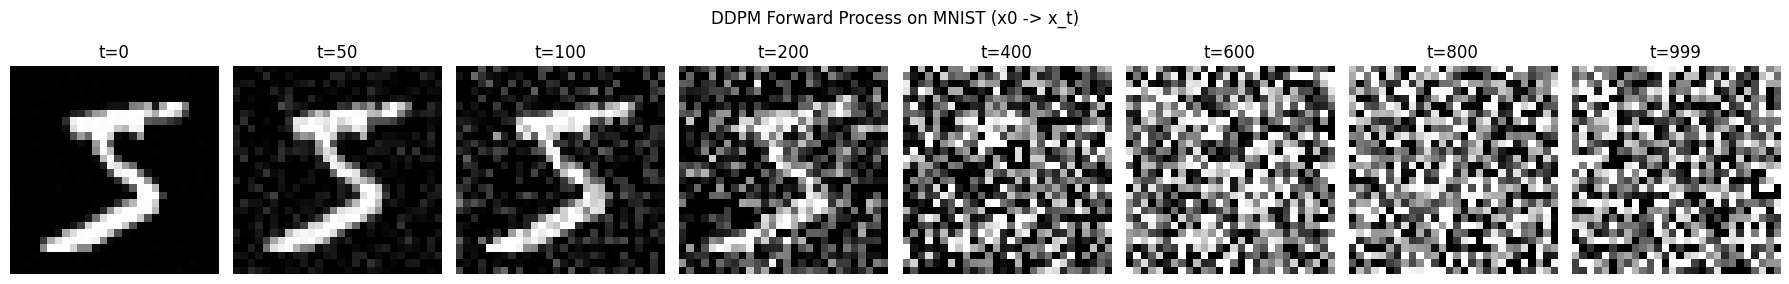

In [42]:
# Forward-process visualization (q(x_t | x_0))
sample_idx = 0
x0, _ = train_dataset[sample_idx]  # x0 in [-1, 1], shape (1, 28, 28)
x0 = x0.unsqueeze(0)  # (1, 1, 28, 28)

timesteps_to_show = [0, 50, 100, 200, 400, 600, 800, NUM_TIMESTEPS - 1]
noisy_images = []

for step in timesteps_to_show:
    t_vis = torch.tensor([step], dtype=torch.long)
    noise = torch.randn_like(x0)
    x_t = dfp.add_noise(x0, noise, t_vis)
    x_t_01 = torch.clamp((x_t + 1.0) / 2.0, 0.0, 1.0)
    noisy_images.append(x_t_01.squeeze(0).squeeze(0).cpu().numpy())

fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(18, 3))
for ax, img, step in zip(axes, noisy_images, timesteps_to_show):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"t={step}")
    ax.axis("off")

plt.suptitle("DDPM Forward Process on MNIST (x0 -> x_t)")
plt.tight_layout()
plt.show()

In [28]:
class DiffusionReverseProcess:
    # Reverse sampling p_theta(x_{t-1} | x_t)
    def __init__(self, num_timesteps: int, beta_start: float, beta_end: float):
        self.num_timesteps = num_timesteps
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, dtype=torch.float32)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.alpha_bars_prev = torch.cat([torch.tensor([1.0]), self.alpha_bars[:-1]], dim=0)

        self.sqrt_alphas = torch.sqrt(self.alphas)
        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)

    @staticmethod
    def _extract(values: Tensor, t: Tensor, x_shape: torch.Size) -> Tensor:
        batch_size = t.shape[0]
        out = values.gather(0, t)
        return out.view(batch_size, *((1,) * (len(x_shape) - 1)))

    def predict_x0(self, xt: Tensor, noise_pred: Tensor, t: Tensor) -> Tensor:
        sqrt_alpha_bar_t = self._extract(self.sqrt_alpha_bars.to(xt.device), t, xt.shape)
        sqrt_one_minus_alpha_bar_t = self._extract(
            self.sqrt_one_minus_alpha_bars.to(xt.device), t, xt.shape
        )
        x0_pred = (xt - sqrt_one_minus_alpha_bar_t * noise_pred) / sqrt_alpha_bar_t
        return torch.clamp(x0_pred, -1.0, 1.0)

    def sample_prev_timestep(self, xt: Tensor, noise_pred: Tensor, t: Tensor) -> Tuple[Tensor, Tensor]:
        x0_pred = self.predict_x0(xt, noise_pred, t)

        betas_t = self._extract(self.betas.to(xt.device), t, xt.shape)
        alphas_t = self._extract(self.alphas.to(xt.device), t, xt.shape)
        alpha_bar_t = self._extract(self.alpha_bars.to(xt.device), t, xt.shape)
        alpha_bar_prev_t = self._extract(self.alpha_bars_prev.to(xt.device), t, xt.shape)

        coef1 = (betas_t * torch.sqrt(alpha_bar_prev_t)) / (1.0 - alpha_bar_t)
        coef2 = ((1.0 - alpha_bar_prev_t) * torch.sqrt(alphas_t)) / (1.0 - alpha_bar_t)
        mean = coef1 * x0_pred + coef2 * xt

        posterior_var = betas_t * (1.0 - alpha_bar_prev_t) / (1.0 - alpha_bar_t)
        noise = torch.randn_like(xt)
        nonzero_mask = (t > 0).float().view(-1, 1, 1, 1)
        x_prev = mean + nonzero_mask * torch.sqrt(torch.clamp(posterior_var, min=1e-20)) * noise

        return x_prev, x0_pred

In [29]:
# Quick reverse-process sanity test
xt = torch.randn(4, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
noise_pred = torch.randn_like(xt)
t = torch.randint(0, NUM_TIMESTEPS, (xt.shape[0],), dtype=torch.long)

drp = DiffusionReverseProcess(NUM_TIMESTEPS, BETA_START, BETA_END)
x_prev, x0 = drp.sample_prev_timestep(xt, noise_pred, t)
x_prev.shape, x0.shape

(torch.Size([4, 1, 28, 28]), torch.Size([4, 1, 28, 28]))

In [30]:
def get_time_embedding(time_steps: Tensor, t_emb_dim: int) -> Tensor:
    # Sinusoidal time embedding used by diffusion models
    assert t_emb_dim % 2 == 0, "Time embedding dimension must be divisible by 2."

    half_dim = t_emb_dim // 2
    exponent = torch.arange(half_dim, device=time_steps.device, dtype=torch.float32)
    exponent = -math.log(10000.0) * exponent / max(half_dim - 1, 1)
    freqs = torch.exp(exponent)

    args = time_steps.float()[:, None] * freqs[None, :]
    t_emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
    return t_emb

In [31]:
# Utility modules
def _valid_num_groups(channels: int, preferred: int = 8) -> int:
    return max(g for g in range(1, preferred + 1) if channels % g == 0)


class NormActConv(nn.Module):
    # GroupNorm -> SiLU -> Conv2d
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        num_groups: int = 8,
        kernel_size: int = 3,
        norm: bool = True,
        act: bool = True,
    ):
        super().__init__()
        groups = _valid_num_groups(in_channels, num_groups)
        self.g_norm = nn.GroupNorm(groups, in_channels) if norm else nn.Identity()
        self.act = nn.SiLU() if act else nn.Identity()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=(kernel_size - 1) // 2,
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.g_norm(x)
        x = self.act(x)
        return self.conv(x)


class TimeEmbedding(nn.Module):
    # MLP projection for timestep embedding
    def __init__(self, n_out: int, t_emb_dim: int = 128):
        super().__init__()
        self.te_block = nn.Sequential(nn.SiLU(), nn.Linear(t_emb_dim, n_out))

    def forward(self, t_emb: Tensor) -> Tensor:
        return self.te_block(t_emb)


class SelfAttentionBlock(nn.Module):
    # Spatial self-attention over flattened HxW tokens
    def __init__(self, num_channels: int, num_groups: int = 8, num_heads: int = 4):
        super().__init__()
        groups = _valid_num_groups(num_channels, num_groups)
        heads = num_heads if num_channels % num_heads == 0 else 1
        self.g_norm = nn.GroupNorm(groups, num_channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=num_channels,
            num_heads=heads,
            batch_first=True,
        )

    def forward(self, x: Tensor) -> Tensor:
        b, c, h, w = x.shape
        x_norm = self.g_norm(x)
        tokens = x_norm.flatten(2).transpose(1, 2)  # (B, HW, C)
        attn_out, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        attn_out = attn_out.transpose(1, 2).reshape(b, c, h, w)
        return x + attn_out


class Downsample(nn.Module):
    # Downsample by factor k using conv path and/or max-pool path
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        k: int = 2,
        use_conv: bool = True,
        use_mpool: bool = True,
    ):
        super().__init__()
        self.use_conv = use_conv
        self.use_mpool = use_mpool

        conv_out = out_channels // 2 if use_conv and use_mpool else out_channels
        pool_out = out_channels // 2 if use_conv and use_mpool else out_channels

        self.cv = (
            nn.Conv2d(in_channels, conv_out, kernel_size=3, stride=k, padding=1)
            if use_conv
            else nn.Identity()
        )
        self.mpool = (
            nn.Sequential(
                nn.MaxPool2d(kernel_size=k, stride=k),
                nn.Conv2d(in_channels, pool_out, kernel_size=1),
            )
            if use_mpool
            else nn.Identity()
        )

    def forward(self, x: Tensor) -> Tensor:
        if not self.use_conv and not self.use_mpool:
            return x
        if not self.use_conv:
            return self.mpool(x)
        if not self.use_mpool:
            return self.cv(x)
        return torch.cat([self.cv(x), self.mpool(x)], dim=1)


class Upsample(nn.Module):
    # Upsample by factor k using transposed-conv path and/or bilinear path
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        k: int = 2,
        use_conv: bool = True,
        use_upsample: bool = True,
    ):
        super().__init__()
        self.use_conv = use_conv
        self.use_upsample = use_upsample

        conv_out = out_channels // 2 if use_conv and use_upsample else out_channels
        up_out = out_channels // 2 if use_conv and use_upsample else out_channels

        self.cv = (
            nn.ConvTranspose2d(
                in_channels,
                conv_out,
                kernel_size=4,
                stride=k,
                padding=1,
            )
            if use_conv
            else nn.Identity()
        )
        self.up = (
            nn.Sequential(
                nn.Upsample(scale_factor=k, mode="bilinear", align_corners=False),
                nn.Conv2d(in_channels, up_out, kernel_size=1),
            )
            if use_upsample
            else nn.Identity()
        )

    def forward(self, x: Tensor) -> Tensor:
        if not self.use_conv and not self.use_upsample:
            return x
        if not self.use_conv:
            return self.up(x)
        if not self.use_upsample:
            return self.cv(x)
        return torch.cat([self.cv(x), self.up(x)], dim=1)

In [32]:
# Utility module sanity test
down = Downsample(32, 64, k=2, use_conv=True, use_mpool=True)
up = Upsample(64, 32, k=2, use_conv=True, use_upsample=True)

x = torch.randn(4, 32, 28, 28)
x_down = down(x)
x_up = up(x_down)
x_down.shape, x_up.shape

(torch.Size([4, 64, 14, 14]), torch.Size([4, 32, 28, 28]))

In [33]:
class DownC(nn.Module):
    """
    Down-convolution block:
    1) ResNet-style conv with time embedding
    2) Self-attention
    3) Optional downsampling
    Returns (downsampled_out, skip_out).
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        t_emb_dim: int = 128,
        num_layers: int = 2,
        down_sample: bool = True,
    ):
        super().__init__()
        self.num_layers = num_layers

        self.conv1 = nn.ModuleList(
            [NormActConv(in_channels if i == 0 else out_channels, out_channels) for i in range(num_layers)]
        )
        self.conv2 = nn.ModuleList([NormActConv(out_channels, out_channels) for _ in range(num_layers)])
        self.te_block = nn.ModuleList([TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)])
        self.attn_block = nn.ModuleList([SelfAttentionBlock(out_channels) for _ in range(num_layers)])
        self.res_block = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.down_block = Downsample(out_channels, out_channels) if down_sample else nn.Identity()

    def forward(self, x: Tensor, t_emb: Tensor) -> Tuple[Tensor, Tensor]:
        out = x
        for i in range(self.num_layers):
            res = out
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](res)
            out = self.attn_block[i](out)

        skip = out
        out = self.down_block(out)
        return out, skip

In [34]:
class MidC(nn.Module):
    """
    Middle block: initial ResNet block, then repeated attention + ResNet refinements.
    """

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        t_emb_dim: int = 128,
        num_layers: int = 2,
    ):
        super().__init__()
        self.num_layers = num_layers

        self.conv1 = nn.ModuleList(
            [NormActConv(in_channels if i == 0 else out_channels, out_channels) for i in range(num_layers + 1)]
        )
        self.conv2 = nn.ModuleList([NormActConv(out_channels, out_channels) for _ in range(num_layers + 1)])
        self.te_block = nn.ModuleList([TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers + 1)])
        self.attn_block = nn.ModuleList([SelfAttentionBlock(out_channels) for _ in range(num_layers)])
        self.res_block = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers + 1)
            ]
        )

    def forward(self, x: Tensor, t_emb: Tensor) -> Tensor:
        out = x

        res = out
        out = self.conv1[0](out)
        out = out + self.te_block[0](t_emb)[:, :, None, None]
        out = self.conv2[0](out)
        out = out + self.res_block[0](res)

        for i in range(self.num_layers):
            out = self.attn_block[i](out)
            res = out
            out = self.conv1[i + 1](out)
            out = out + self.te_block[i + 1](t_emb)[:, :, None, None]
            out = self.conv2[i + 1](out)
            out = out + self.res_block[i + 1](res)

        return out

In [35]:
class UpC(nn.Module):
    """
    Up-convolution block:
    1) Optional upsampling
    2) Concatenate skip features
    3) ResNet-style conv with time embedding
    4) Self-attention
    """

    def __init__(
        self,
        in_channels: int,
        skip_channels: int,
        out_channels: int,
        t_emb_dim: int = 128,
        num_layers: int = 2,
        up_sample: bool = True,
    ):
        super().__init__()
        self.num_layers = num_layers

        self.up_block = Upsample(in_channels, out_channels) if up_sample else nn.Identity()
        merged_channels = out_channels + skip_channels if up_sample else in_channels + skip_channels

        self.conv1 = nn.ModuleList(
            [NormActConv(merged_channels if i == 0 else out_channels, out_channels) for i in range(num_layers)]
        )
        self.conv2 = nn.ModuleList([NormActConv(out_channels, out_channels) for _ in range(num_layers)])
        self.te_block = nn.ModuleList([TimeEmbedding(out_channels, t_emb_dim) for _ in range(num_layers)])
        self.attn_block = nn.ModuleList([SelfAttentionBlock(out_channels) for _ in range(num_layers)])
        self.res_block = nn.ModuleList(
            [
                nn.Conv2d(merged_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )

    def forward(self, x: Tensor, skip: Tensor, t_emb: Tensor) -> Tensor:
        x = self.up_block(x)
        out = torch.cat([x, skip], dim=1)

        for i in range(self.num_layers):
            res = out
            out = self.conv1[i](out)
            out = out + self.te_block[i](t_emb)[:, :, None, None]
            out = self.conv2[i](out)
            out = out + self.res_block[i](res)
            out = self.attn_block[i](out)

        return out

In [36]:
class Unet(nn.Module):
    """
    DDPM U-Net noise predictor epsilon_theta(x_t, t).
    """

    def __init__(
        self,
        im_channels: int = 1,
        down_ch: tuple[int, ...] = (32, 64, 128, 256),
        mid_ch: tuple[int, ...] = (256, 256, 256),
        down_sample: tuple[bool, ...] = (True, True, False),
        t_emb_dim: int = 128,
        num_downc_layers: int = 2,
        num_midc_layers: int = 2,
        num_upc_layers: int = 2,
    ):
        super().__init__()

        assert len(down_sample) == len(down_ch) - 1

        self.im_channels = im_channels
        self.down_ch = down_ch
        self.mid_ch = mid_ch
        self.t_emb_dim = t_emb_dim
        self.up_sample = tuple(reversed(down_sample))

        self.cv1 = nn.Conv2d(im_channels, down_ch[0], kernel_size=3, padding=1)

        self.t_proj = nn.Sequential(
            nn.Linear(t_emb_dim, t_emb_dim),
            nn.SiLU(),
            nn.Linear(t_emb_dim, t_emb_dim),
        )

        self.downs = nn.ModuleList(
            [
                DownC(
                    in_channels=down_ch[i],
                    out_channels=down_ch[i + 1],
                    t_emb_dim=t_emb_dim,
                    num_layers=num_downc_layers,
                    down_sample=down_sample[i],
                )
                for i in range(len(down_ch) - 1)
            ]
        )

        self.mids = nn.ModuleList(
            [
                MidC(
                    in_channels=mid_ch[i],
                    out_channels=mid_ch[i + 1],
                    t_emb_dim=t_emb_dim,
                    num_layers=num_midc_layers,
                )
                for i in range(len(mid_ch) - 1)
            ]
        )

        skip_channels = list(reversed(down_ch[1:]))
        up_out_channels = [256, 128, 64]
        up_in_channels = [mid_ch[-1]] + up_out_channels[:-1]

        self.ups = nn.ModuleList(
            [
                UpC(
                    in_channels=up_in_channels[i],
                    skip_channels=skip_channels[i],
                    out_channels=up_out_channels[i],
                    t_emb_dim=t_emb_dim,
                    num_layers=num_upc_layers,
                    up_sample=self.up_sample[i],
                )
                for i in range(len(up_out_channels))
            ]
        )

        self.cv2 = nn.Sequential(
            nn.GroupNorm(_valid_num_groups(up_out_channels[-1]), up_out_channels[-1]),
            nn.SiLU(),
            nn.Conv2d(up_out_channels[-1], im_channels, kernel_size=3, padding=1),
        )

    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        out = self.cv1(x)

        t_emb = get_time_embedding(t, self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        skips = []
        for down in self.downs:
            out, skip = down(out, t_emb)
            skips.append(skip)

        for mid in self.mids:
            out = mid(out, t_emb)

        for up in self.ups:
            skip = skips.pop()
            out = up(out, skip, t_emb)

        return self.cv2(out)

In [37]:
# U-Net shape sanity test
model = Unet(
    im_channels=NUM_CHANNELS,
    down_ch=(BASE_CHANNELS, BASE_CHANNELS * 2, BASE_CHANNELS * 4, BASE_CHANNELS * 8),
    mid_ch=(BASE_CHANNELS * 8, BASE_CHANNELS * 8, BASE_CHANNELS * 8),
    down_sample=(True, True, False),
    t_emb_dim=T_EMB_DIM,
    num_downc_layers=NUM_LAYERS_MODULE,
    num_midc_layers=NUM_LAYERS_MODULE,
    num_upc_layers=NUM_LAYERS_MODULE,
)

x = torch.randn(4, NUM_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)
t = torch.randint(0, NUM_TIMESTEPS, (4,), dtype=torch.long)
model(x, t).shape

torch.Size([4, 1, 28, 28])

In [38]:
model = Unet(
    im_channels=NUM_CHANNELS,
    down_ch=(BASE_CHANNELS, BASE_CHANNELS * 2, BASE_CHANNELS * 4, BASE_CHANNELS * 8),
    mid_ch=(BASE_CHANNELS * 8, BASE_CHANNELS * 8, BASE_CHANNELS * 8),
    down_sample=(True, True, False),
    t_emb_dim=T_EMB_DIM,
    num_downc_layers=NUM_LAYERS_MODULE,
    num_midc_layers=NUM_LAYERS_MODULE,
    num_upc_layers=NUM_LAYERS_MODULE,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(BETA1, BETA2), eps=EPS)
criterion = nn.MSELoss()

dfp = DiffusionForwardProcess(NUM_TIMESTEPS, BETA_START, BETA_END)

best_train_loss = float("inf")
epoch_noise_losses = []  # Mean epsilon-prediction (noise) loss per epoch
print("Starting DDPM training loop...")
training_start = time.perf_counter()

for epoch in range(EPOCHS):
    model.train()
    losses = []

    for imgs, _ in train_loader:
        imgs = imgs.to(device, non_blocking=True)

        noise = torch.randn_like(imgs)
        t = torch.randint(0, NUM_TIMESTEPS, (imgs.shape[0],), device=device, dtype=torch.long)

        noisy_imgs = dfp.add_noise(imgs, noise, t)
        noise_pred = model(noisy_imgs, t)

        loss = criterion(noise_pred, noise)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    mean_epoch_loss = float(np.mean(losses))
    epoch_noise_losses.append(mean_epoch_loss)
    print(f"Epoch [{epoch + 1}/{EPOCHS}] - Loss: {mean_epoch_loss:.6f}")

    if mean_epoch_loss < best_train_loss:
        best_train_loss = mean_epoch_loss
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "config": {
                    "im_channels": NUM_CHANNELS,
                    "down_ch": (BASE_CHANNELS, BASE_CHANNELS * 2, BASE_CHANNELS * 4, BASE_CHANNELS * 8),
                    "mid_ch": (BASE_CHANNELS * 8, BASE_CHANNELS * 8, BASE_CHANNELS * 8),
                    "down_sample": (True, True, False),
                    "t_emb_dim": T_EMB_DIM,
                    "num_downc_layers": NUM_LAYERS_MODULE,
                    "num_midc_layers": NUM_LAYERS_MODULE,
                    "num_upc_layers": NUM_LAYERS_MODULE,
                    "num_timesteps": NUM_TIMESTEPS,
                    "beta_start": BETA_START,
                    "beta_end": BETA_END,
                },
                "best_train_loss": best_train_loss,
                "seed": SEED,
            },
            CHECKPOINT_PATH,
        )
        print(f"Saved checkpoint to {CHECKPOINT_PATH} (best loss: {best_train_loss:.6f})")

training_seconds = time.perf_counter() - training_start
print(f"Training completed in {training_seconds:.2f} seconds.")

# Plot noise-prediction loss vs epochs
plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS + 1), epoch_noise_losses, marker="o", linewidth=2)
plt.title("DDPM Noise Prediction Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Starting DDPM training loop...
Epoch [1/5] - Loss: 0.079148
Saved checkpoint to outputs/ddpm/ddpm_unet_mnist.pt (best loss: 0.079148)
Epoch [2/5] - Loss: 0.035021
Saved checkpoint to outputs/ddpm/ddpm_unet_mnist.pt (best loss: 0.035021)
Epoch [3/5] - Loss: 0.030897
Saved checkpoint to outputs/ddpm/ddpm_unet_mnist.pt (best loss: 0.030897)
Epoch [4/5] - Loss: 0.027999
Saved checkpoint to outputs/ddpm/ddpm_unet_mnist.pt (best loss: 0.027999)
Epoch [5/5] - Loss: 0.026687
Saved checkpoint to outputs/ddpm/ddpm_unet_mnist.pt (best loss: 0.026687)
Training completed in 1894.67 seconds.


In [39]:
def load_trained_model(checkpoint_path: Path = CHECKPOINT_PATH) -> tuple[Unet, dict]:
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"Checkpoint not found at {checkpoint_path}. Train first or update CHECKPOINT_PATH."
        )

    checkpoint = torch.load(checkpoint_path, map_location=device)
    cfg = checkpoint["config"]

    model = Unet(
        im_channels=cfg["im_channels"],
        down_ch=tuple(cfg["down_ch"]),
        mid_ch=tuple(cfg["mid_ch"]),
        down_sample=tuple(cfg["down_sample"]),
        t_emb_dim=cfg["t_emb_dim"],
        num_downc_layers=cfg["num_downc_layers"],
        num_midc_layers=cfg["num_midc_layers"],
        num_upc_layers=cfg["num_upc_layers"],
    ).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, cfg


@torch.no_grad()
def generate_samples(
    model: Unet,
    cfg: dict,
    num_images: int = 64,
    batch_size: int = 64,
) -> Tensor:
    drp = DiffusionReverseProcess(
        cfg["num_timesteps"],
        cfg["beta_start"],
        cfg["beta_end"],
    )

    all_samples = []
    images_left = num_images

    while images_left > 0:
        curr_bs = min(batch_size, images_left)
        xt = torch.randn(curr_bs, cfg["im_channels"], IMAGE_SIZE, IMAGE_SIZE, device=device)

        for step in reversed(range(cfg["num_timesteps"])):
            t = torch.full((curr_bs,), step, device=device, dtype=torch.long)
            noise_pred = model(xt, t)
            xt, _ = drp.sample_prev_timestep(xt, noise_pred, t)

        xt = torch.clamp(xt, -1.0, 1.0)
        all_samples.append(xt.cpu())
        images_left -= curr_bs

    return torch.cat(all_samples, dim=0)


def denorm_to_01(x: Tensor) -> Tensor:
    return torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)

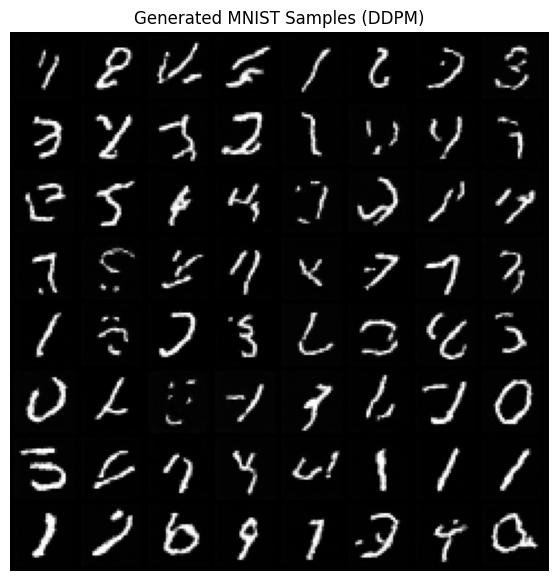

In [40]:
trained_model, trained_cfg = load_trained_model(CHECKPOINT_PATH)
generated = generate_samples(
    trained_model,
    trained_cfg,
    num_images=NUM_IMG_TO_GENERATE,
    batch_size=EVAL_BATCH_SIZE,
)

generated_01 = denorm_to_01(generated)

grid = vutils.make_grid(generated_01[:64], nrow=8, padding=2)
plt.figure(figsize=(7, 7))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis("off")
plt.title("Generated MNIST Samples (DDPM)")
plt.show()

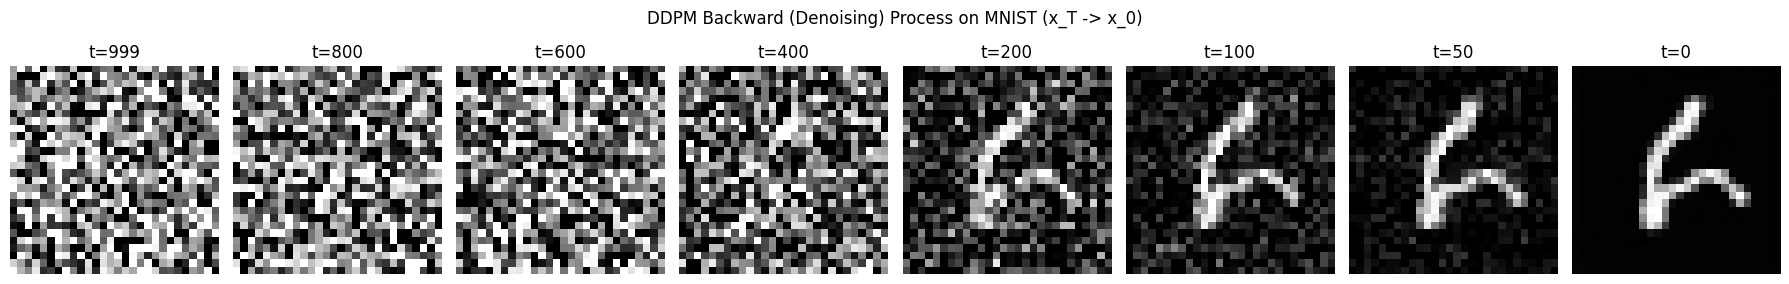

In [43]:
# Backward-process visualization (p_theta(x_{t-1} | x_t))
@torch.no_grad()
def visualize_backward_process(model: Unet, cfg: dict, seed: int = 42):
    torch.manual_seed(seed)

    drp_vis = DiffusionReverseProcess(
        cfg["num_timesteps"],
        cfg["beta_start"],
        cfg["beta_end"],
    )

    steps_to_show = [cfg["num_timesteps"] - 1, 800, 600, 400, 200, 100, 50, 0]
    snapshots = {}

    xt = torch.randn(1, cfg["im_channels"], IMAGE_SIZE, IMAGE_SIZE, device=device)
    snapshots[cfg["num_timesteps"] - 1] = xt.detach().cpu()

    for step in reversed(range(cfg["num_timesteps"])):
        t = torch.full((1,), step, device=device, dtype=torch.long)
        noise_pred = model(xt, t)
        xt, _ = drp_vis.sample_prev_timestep(xt, noise_pred, t)
        if step in steps_to_show:
            snapshots[step] = xt.detach().cpu()

    ordered_steps = [s for s in steps_to_show if s in snapshots]
    fig, axes = plt.subplots(1, len(ordered_steps), figsize=(18, 3))

    for ax, step in zip(axes, ordered_steps):
        img = torch.clamp((snapshots[step] + 1.0) / 2.0, 0.0, 1.0)[0, 0].numpy()
        ax.imshow(img, cmap="gray")
        ax.set_title(f"t={step}")
        ax.axis("off")

    plt.suptitle("DDPM Backward (Denoising) Process on MNIST (x_T -> x_0)")
    plt.tight_layout()
    plt.show()


visualize_backward_process(trained_model, trained_cfg, seed=SEED)

In [41]:
@torch.no_grad()
def collect_real_images(num_images: int) -> Tensor:
    real_batches = []
    collected = 0
    for imgs, _ in test_loader:
        real_batches.append(imgs)
        collected += imgs.shape[0]
        if collected >= num_images:
            break
    return torch.cat(real_batches, dim=0)[:num_images]


def to_uint8_for_fid(x: Tensor) -> Tensor:
    x01 = denorm_to_01(x)
    return (x01 * 255.0).to(torch.uint8)


num_eval = min(1024, generated.shape[0], len(test_dataset))

real_eval = collect_real_images(num_eval)
gen_eval = generated[:num_eval]

# SSIM over grayscale images in [0, 1]
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
ssim_score = ssim_metric(
    denorm_to_01(gen_eval).to(device),
    denorm_to_01(real_eval).to(device),
).item()

# FID expects RGB uint8 images; replicate channels from grayscale
fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
real_uint8 = to_uint8_for_fid(real_eval).repeat(1, 3, 1, 1).to(device)
gen_uint8 = to_uint8_for_fid(gen_eval).repeat(1, 3, 1, 1).to(device)

fid_metric.update(real_uint8, real=True)
fid_metric.update(gen_uint8, real=False)
fid_score = fid_metric.compute().item()

print(f"Evaluation samples: {num_eval}")
print(f"SSIM (higher is better): {ssim_score:.4f}")
print(f"FID  (lower is better):  {fid_score:.4f}")

Evaluation samples: 256
SSIM (higher is better): 0.2790
FID  (lower is better):  59.1958
